## GLOBAL PRODUCT SALES DATA ANALYSIS

## Importing the necessary libraries


In [2]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

## Importing the data 

In [3]:
# reading the data from the csv file.
DF = pd.read_csv("samsung_global_sales_dataset.csv")
DF

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1.130820e+06,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1.322152e+06,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1.964399e+06,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,6.603595e+05,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2.835246e+06,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15495,SAMS-00015496,2024-08-08,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Galaxy A54 5G,Galaxy A,...,VND,24500.0,1.168332e+07,Samsung Store,BNPL (Buy Now Pay Later),Government,25–34,Android (Samsung),4.0,Kept
15496,SAMS-00015497,2024-08-10,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Neo QLED 8K QN900C,Smart TV,...,VND,24500.0,3.520981e+08,Carrier Store,EMI / Installment,Government,55+,NaN,NaN,Returned
15497,SAMS-00015498,2024-09-15,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung Galaxy Watch 6,Galaxy Watch,...,VND,24500.0,1.373323e+07,Online (Samsung.com),Credit Card,Enterprise,45–54,NaN,NaN,Kept
15498,SAMS-00015499,2024-09-16,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung 25L Microwave,Appliances,...,VND,24500.0,3.982720e+06,Third-Party Retailer,Debit Card,Business,18–24,NaN,3.3,Kept


# Link of the kaggle dataset that was imported
https://www.kaggle.com/datasets/ashyou09/samsung-global-product-sales-dataset

## Data Quality Check

In [4]:
# Showing the top 5 records of the dataset
pd.set_option("display.max_columns",None)
DF.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,is_5g,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,1 TB,Graphite,No,1246.77,0,1,1246.77,1246.77,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,1 TB,Titanium Violet,Yes,809.84,10,2,728.86,1457.72,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,128 GB,Awesome Black,Yes,410.19,12,6,360.97,2165.82,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,NaN,Black,No,242.69,0,3,242.69,728.07,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,256 GB,Cream,Yes,1562.98,0,2,1562.98,3125.96,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [5]:
# Verifying the variables and the individuals in the above dataset
DF.shape

(15500, 28)

In [6]:
# Finding the null
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 7651 non-null   object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

# Columns which have null
1. storage -> object(dtype)
2. previous_device_os -> object(dtype)
3. customer_rating -> float 64(dtype)

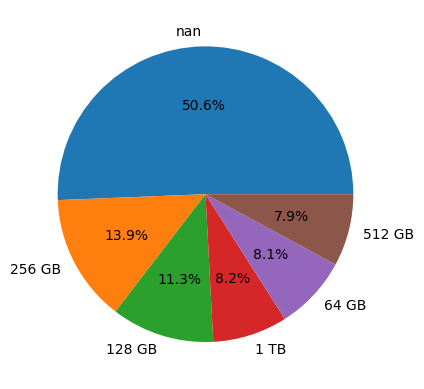

In [7]:
# Finding null percentage in other two columns  
sto = DF["storage"].value_counts(dropna = False)
plt.pie(x=sto.values,labels = sto.index,autopct = "%1.1f%%")
plt.show()

In [205]:
# Category wise Null values for customer rating.
DF.groupby("category")["customer_rating"].apply(lambda x: x.isna().sum())

category
Accessories     597
Appliances      285
Galaxy A        504
Galaxy Buds     247
Galaxy M        225
Galaxy S        647
Galaxy Tab      431
Galaxy Watch    394
Galaxy Z        277
Monitor         295
Smart TV        349
Name: customer_rating, dtype: int64

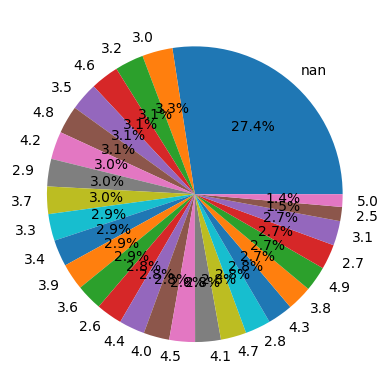

In [8]:
# Find how much null present in the customer rating column
cust_rat = DF["customer_rating"].value_counts(dropna = False)
plt.pie(x=cust_rat.values,labels=cust_rat.index,autopct = "%1.1f%%")
plt.show()

In [9]:
# Finding the percentage of the null in the previous_OS column
prev_dev_os = DF["previous_device_os"].value_counts(dropna = False)

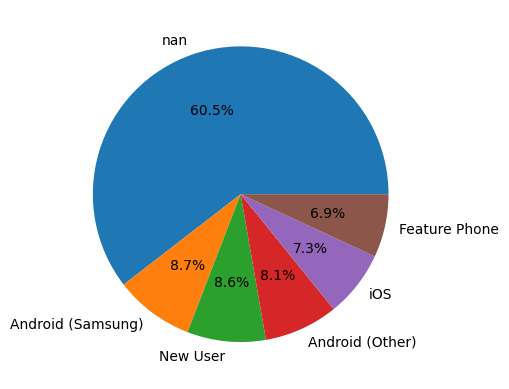

In [10]:
plt.pie(x = prev_dev_os.values,labels = prev_dev_os.index,autopct = "%1.1f%%")
plt.show()

In [11]:
# Checking whether the table have duplicates
DF.duplicated().sum()

np.int64(0)

In [12]:
# Finding the outlier
DF.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color', 'is_5g',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

In [13]:
# Creating new dataframe from exisiting dataframe in order to analyze the outlier
Numerical_col = DF[["unit_price_usd","discount_pct","units_sold","discounted_price_usd","revenue_usd"]]
Numerical_col

,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd
0,1246.77,0,1,1246.77,1246.77
1,809.84,10,2,728.86,1457.72
2,410.19,12,6,360.97,2165.82
3,242.69,0,3,242.69,728.07
4,1562.98,0,2,1562.98,3125.96
...,...,...,...,...,...
15495,476.87,0,1,476.87,476.87
15496,4790.45,0,3,4790.45,14371.35
15497,295.02,5,2,280.27,560.54
15498,191.25,15,1,162.56,162.56


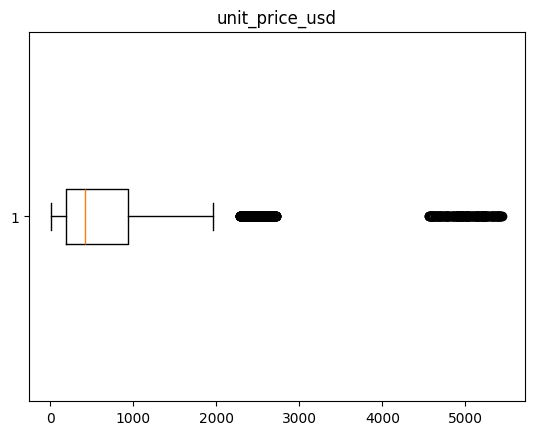

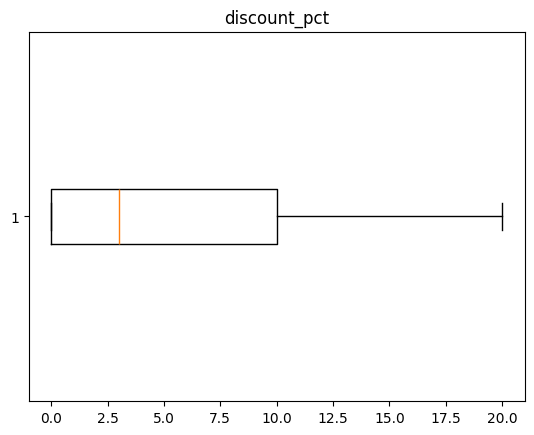

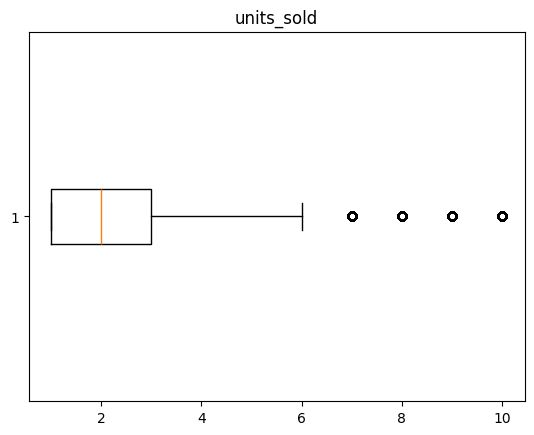

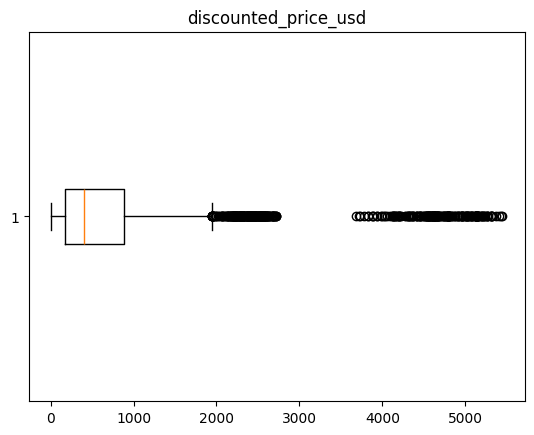

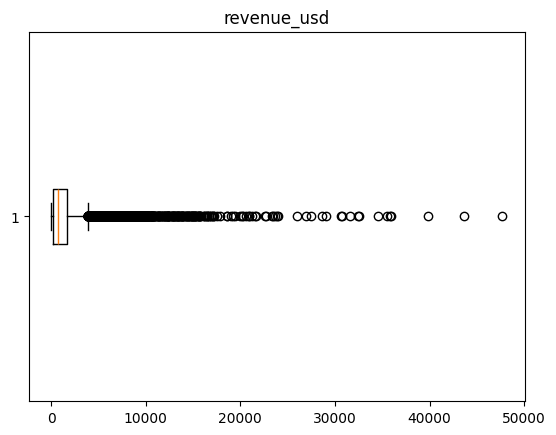

In [204]:
# Box plot visualization to indentify the outliers values inorder to handle the null.
for i in Numerical_col:
    plt.boxplot(x = DF[str(i)],vert = False)
    plt.title(i)
    plt.show()

In [15]:
# Basic statistics 
Numerical_col.describe()

,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000
mean,665.116825,5.708452,2.360000,627.134001,1478.145734
std,736.014360,6.406814,1.897958,695.723305,2368.688098
min,8.200000,0.000000,1.000000,6.600000,6.610000
25%,185.435000,0.000000,1.000000,172.780000,254.265000
50%,421.490000,3.000000,2.000000,397.410000,739.380000
75%,938.657500,10.000000,3.000000,882.907500,1695.315000
max,5442.700000,20.000000,10.000000,5442.700000,47665.900000


In [16]:
# Describing each and every column
DF.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,1.550000e+04,11249.000000
mean,2022.511935,665.116825,5.708452,2.360000,627.134001,1478.145734,1054.528710,1.595853e+06,3.743515
std,1.113496,736.014360,6.406814,1.897958,695.723305,2368.688098,4062.232887,1.092157e+07,0.721258
min,2021.000000,8.200000,0.000000,1.000000,6.600000,6.610000,0.790000,6.080000e+00,2.500000
25%,2022.000000,185.435000,0.000000,1.000000,172.780000,254.265000,1.360000,1.199072e+03,3.100000
50%,2023.000000,421.490000,3.000000,2.000000,397.410000,739.380000,10.650000,7.813940e+03,3.700000
75%,2024.000000,938.657500,10.000000,3.000000,882.907500,1695.315000,110.000000,9.126992e+04,4.400000
max,2024.000000,5442.700000,20.000000,10.000000,5442.700000,47665.900000,24500.000000,3.647727e+08,5.000000


In [17]:
#checking for neagtive values in all the numeric column
list = []
for i in Numerical_col:
    sum_neg_value = (DF[str(i)].values < 0).sum()
    list.append(sum_neg_value)
print(list)

[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


## Summary
 1.Found null values and percentage of it in three columns.
 
 2.Verified whether there is duplicate or not.
 
 3.Found some outliers are there in the columns and visualized them.

 4.The numeric columns in the dataset has no negative values and logically it should be non-negative as well.

 

# Exploratory Data Analysis

In [19]:
# Getting the column names
DF.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color', 'is_5g',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

In [149]:
# Creating a dataframe with the required  column.
DF_Final = DF[['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region','city', 'product_name', 'category', 'storage', 'color', 'is_5g','unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd','revenue_usd','sales_channel', 'payment_method', 'customer_segment','customer_age_group','customer_rating','return_status']].copy()

In [150]:
# showing the data frame
DF_Final

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,is_5g,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,sales_channel,payment_method,customer_segment,customer_age_group,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,1 TB,Graphite,No,1246.77,0,1,1246.77,1246.77,E-commerce Platform,Samsung Pay,Business,45–54,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,1 TB,Titanium Violet,Yes,809.84,10,2,728.86,1457.72,Authorized Reseller,Net Banking,Government,55+,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,128 GB,Awesome Black,Yes,410.19,12,6,360.97,2165.82,Corporate / B2B,Gift Card,Individual,25–34,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,NaN,Black,No,242.69,0,3,242.69,728.07,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,256 GB,Cream,Yes,1562.98,0,2,1562.98,3125.96,Authorized Reseller,Gift Card,Business,55+,3.0,Kept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15495,SAMS-00015496,2024-08-08,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Galaxy A54 5G,Galaxy A,64 GB,Awesome Violet,Yes,476.87,0,1,476.87,476.87,Samsung Store,BNPL (Buy Now Pay Later),Government,25–34,4.0,Kept
15496,SAMS-00015497,2024-08-10,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Neo QLED 8K QN900C,Smart TV,NaN,Black,No,4790.45,0,3,4790.45,14371.35,Carrier Store,EMI / Installment,Government,55+,NaN,Returned
15497,SAMS-00015498,2024-09-15,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung Galaxy Watch 6,Galaxy Watch,NaN,Cream,No,295.02,5,2,280.27,560.54,Online (Samsung.com),Credit Card,Enterprise,45–54,NaN,Kept
15498,SAMS-00015499,2024-09-16,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung 25L Microwave,Appliances,NaN,Silver,No,191.25,15,1,162.56,162.56,Third-Party Retailer,Debit Card,Business,18–24,3.3,Kept


# UNIT PRICE

<Axes: xlabel='unit_price_usd', ylabel='Count'>

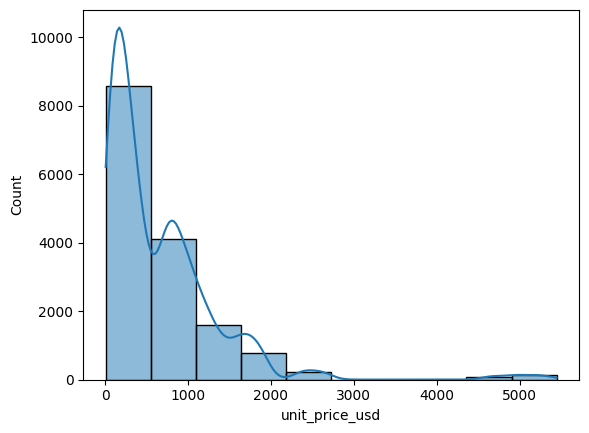

In [151]:
# Analyzing the data distribution of the unit price.
sns.histplot(data = DF_Final,x="unit_price_usd",bins = 10,kde = True)

# Observation
The sales was high when the price of the product is around 200.

In [152]:
# Picking the unit_price_usd
age = DF_Final["customer_age_group"].value_counts().sort_index()

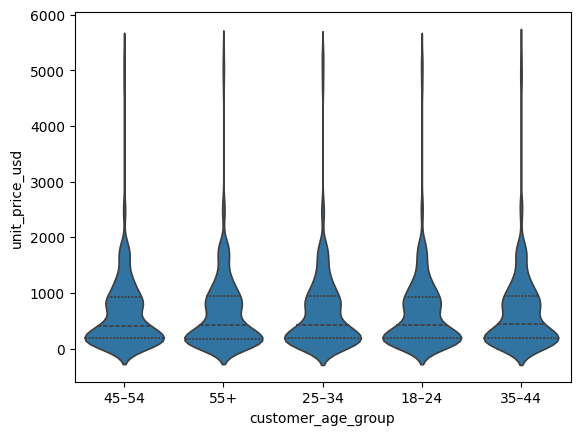

In [153]:
# plotting the violin plot
sns.violinplot(data = DF_Final, x= "customer_age_group", y = "unit_price_usd", inner = "quart")
#zoom into 0 to 1000 range only
# plt.ylim(0, 1000)    
plt.show()


# Observation

    1.No significant preference price for the individual age groups.
  
    2.Most of our customers are buying products around 200 and few above 200.

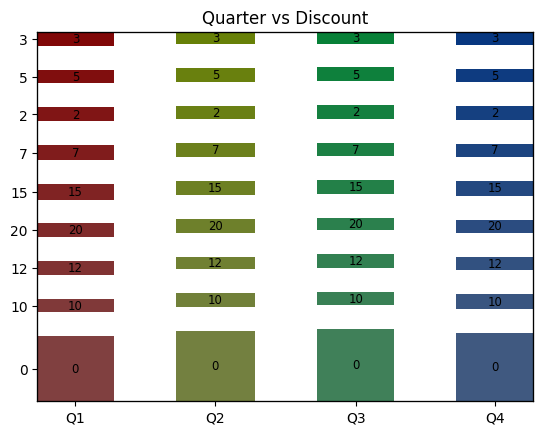

In [154]:
mosaic(DF_Final,["quarter","discount_pct"],gap=0.2,title="Quarter vs Discount",labelizer=lambda k: k[1])
plt.show()

In [155]:
pd.crosstab(
    DF_Final['discount_pct'],
    DF_Final['quarter']
)

quarter,Q1,Q2,Q3,Q4
discount_pct,,,,
0,1395,1561,1548,1475
2,300,294,293,301
3,299,285,255,284
5,296,311,299,292
7,316,312,295,283
10,269,321,287,324
12,307,276,306,298
15,333,313,289,327
20,294,313,264,285


## Observation
The relationship between the discount and quarter shows that there is no significant impact on discount because of the quarter or time.The discount remains same regardless of the quarter.

# UNIT SOLD

In [156]:
# Extracting the required variable for further analysis
Cat_wise_sales = DF_Final.groupby('category').sum()[["units_sold"]]
Cat_wise_sales

,units_sold
category,
Accessories,4875
Appliances,2508
Galaxy A,4498
Galaxy Buds,1998
Galaxy M,2112
Galaxy S,5567
Galaxy Tab,3706
Galaxy Watch,3453
Galaxy Z,2436


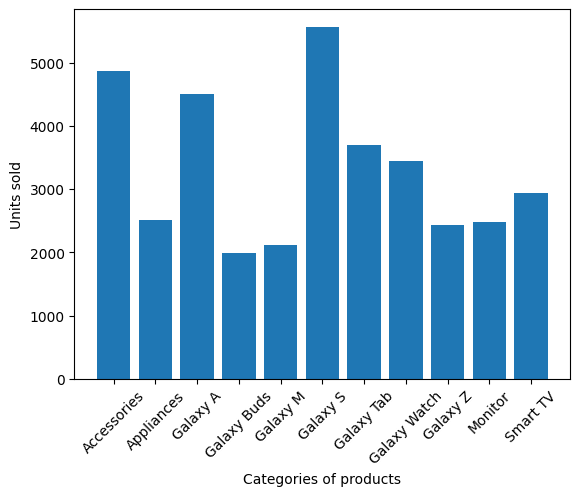

In [157]:
#Plotting the bar chart to analyse the unit sold on different categories.
plt.bar(x=Cat_wise_sales.index,height = Cat_wise_sales["units_sold"])
plt.xticks(rotation = 45)
plt.xlabel("Categories of products")
plt.ylabel("Units sold")
plt.show()

# Observation
1. Among the categories available the Galaxy S sold out well followed by that Accessories sold well.
2. The Galaxy Buds sold out range is not good enough since improvement need to taken.

In [158]:
# Region wise unit price analysis.
region_wise_sales = DF_Final.groupby(['region'])["units_sold"].sum().sort_values(ascending = False)
region_wise_sales

region
Europe           12517
Asia             10739
Africa            3522
South America     3466
North America     2169
Middle East       1408
Europe/Asia       1386
Oceania           1373
Name: units_sold, dtype: int64

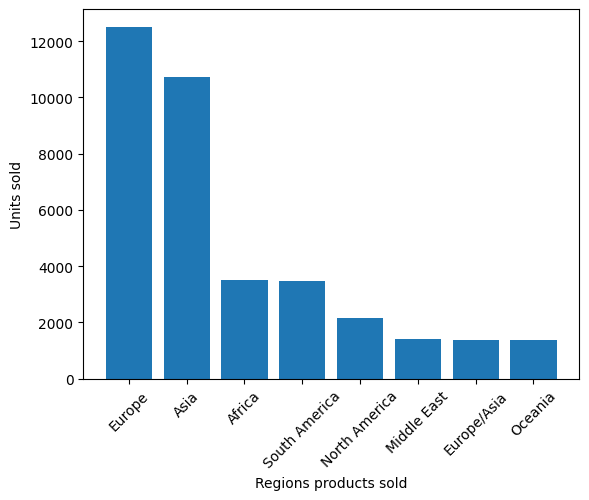

In [159]:
# Unit sold based on the region.
plt.bar(x= region_wise_sales.index,height = region_wise_sales.values)
plt.xticks(rotation = 45)
plt.xlabel("Regions products sold")
plt.ylabel("Units sold")
plt.show()

## Observation
1.The products were sold the most in Europe and Asia, with around 12,500 and 10,700 units sold respectively.

2.The other regions range between roughly 1,300 to 3,500 units sold, much lower than Europe and Asia.

In [160]:
# Unit sold based on channel.
channel_wise_sales = DF_Final.groupby(['sales_channel']).sum()[["units_sold"]].sort_values("units_sold")
channel_wise_sales

,units_sold
sales_channel,
Third-Party Retailer,5061
Online (Samsung.com),5063
Authorized Reseller,5156
Carrier Store,5164
Samsung Store,5367
E-commerce Platform,5368
Corporate / B2B,5401


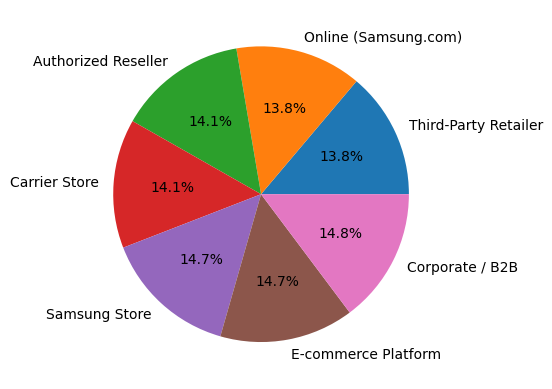

In [161]:
# Creating pie chart using the sales channel and units sold to know the rate at which all the sales unit hold.
plt.pie(x = channel_wise_sales["units_sold"],labels = channel_wise_sales.index,autopct = "%1.1f%%")
plt.show()

## Observation
1. All the channel sales range seems to be in the range from 13.8 to 14.8 not big impact was noticed only the minute rate differnce.
2. Among them Corporate/B2B holds the first place.

In [162]:
# Analysis based on the customer segment.
Cust_wise_unit_sold = DF_Final.groupby('customer_segment')[["units_sold"]].sum()
Cust_wise_unit_sold.sort_values("units_sold",inplace = True)
Cust_wise_unit_sold

,units_sold
customer_segment,
Enterprise,7101
Education,7176
Business,7368
Government,7432
Individual,7503


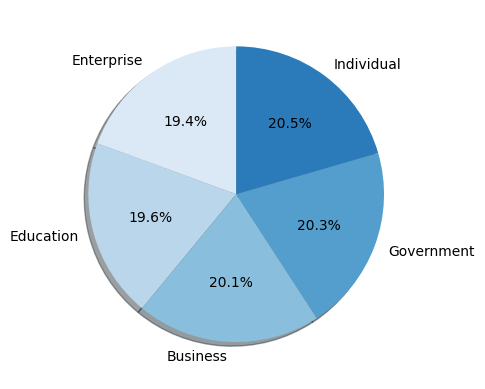

In [163]:
# Using the pie chart
color = sns.color_palette("Blues")
plt.pie(x = Cust_wise_unit_sold["units_sold"] ,labels = Cust_wise_unit_sold.index, colors = color,autopct = "%1.1f%%",shadow = True,startangle =90)
plt.show()

## Observation
1. The Indivisual category buys our product more follows by the Government and the Business.

## TIME SERIES ANALYSIS FOR UNITS SOLD

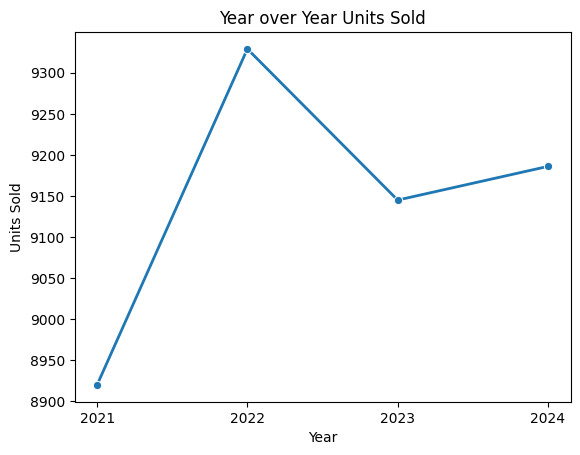

In [164]:
# Year Over Year Analysis
DF_Final["year"] = DF_Final["year"].astype("str")
yearly = DF_Final.groupby('year')['units_sold'].sum().reset_index()

sns.lineplot(
    data=yearly,
    x='year',
    y='units_sold',
    marker='o',
    linewidth=2
)

plt.title('Year over Year Units Sold')
plt.xlabel('Year')
plt.ylabel('Units Sold')
plt.show()

# Observation
 In the above the sales increases from the year 2021 to 2022 but falls after that need to find the reason for that.

In [165]:
yearly_unitprice =  DF_Final.groupby('year')['unit_price_usd'].sum().reset_index()
yearly_unitprice

,year,unit_price_usd
0,2021,2484557.50
1,2022,2620333.43
2,2023,2642233.00
3,2024,2562186.86


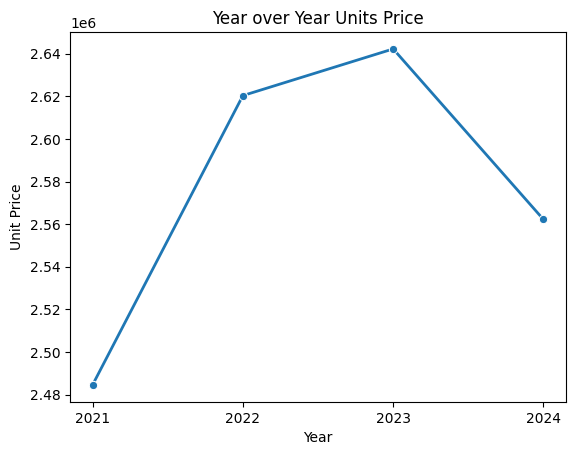

In [166]:
# Year Over Year Analysis for unit price.
sns.lineplot(
    data = yearly_unitprice,
    x='year',
    y='unit_price_usd',
    marker='o',
    linewidth=2
)

plt.title('Year over Year Units Price')
plt.xlabel('Year')
plt.ylabel('Unit Price')
plt.show()

# Observation
The unit price of the product seems to be increase from the year 2021 to 2023 then it drops after that.

In [167]:
DF_Final

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,is_5g,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,sales_channel,payment_method,customer_segment,customer_age_group,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,1 TB,Graphite,No,1246.77,0,1,1246.77,1246.77,E-commerce Platform,Samsung Pay,Business,45–54,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,1 TB,Titanium Violet,Yes,809.84,10,2,728.86,1457.72,Authorized Reseller,Net Banking,Government,55+,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,128 GB,Awesome Black,Yes,410.19,12,6,360.97,2165.82,Corporate / B2B,Gift Card,Individual,25–34,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,NaN,Black,No,242.69,0,3,242.69,728.07,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,256 GB,Cream,Yes,1562.98,0,2,1562.98,3125.96,Authorized Reseller,Gift Card,Business,55+,3.0,Kept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15495,SAMS-00015496,2024-08-08,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Galaxy A54 5G,Galaxy A,64 GB,Awesome Violet,Yes,476.87,0,1,476.87,476.87,Samsung Store,BNPL (Buy Now Pay Later),Government,25–34,4.0,Kept
15496,SAMS-00015497,2024-08-10,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Neo QLED 8K QN900C,Smart TV,NaN,Black,No,4790.45,0,3,4790.45,14371.35,Carrier Store,EMI / Installment,Government,55+,NaN,Returned
15497,SAMS-00015498,2024-09-15,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung Galaxy Watch 6,Galaxy Watch,NaN,Cream,No,295.02,5,2,280.27,560.54,Online (Samsung.com),Credit Card,Enterprise,45–54,NaN,Kept
15498,SAMS-00015499,2024-09-16,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung 25L Microwave,Appliances,NaN,Silver,No,191.25,15,1,162.56,162.56,Third-Party Retailer,Debit Card,Business,18–24,3.3,Kept


In [168]:
DF_Final["year"].dtype

dtype('O')

## Quarter Over Quarter Analysis FOR UNIT SOLD

In [169]:
# Plotting the line plot for each year for different quarter
def final_plt(df,year):
    x = sns.lineplot(data = df, x = "quarter",y = "units_sold", marker = "o",linewidth = 2)
    x = plt.title('Quarter over Quarter Units Sold for year '+ year)
    x = plt.xlabel('Quarter')
    x = plt.ylabel('Units Sold')
    x = plt.show()
    return x

In [170]:
# Grouping the datset based on the quarter
def grouping_quarter(yearAfterFilter,year):
    DF_year = yearAfterFilter.groupby("quarter")["units_sold"].sum().reset_index()
    return final_plt(DF_year,year)


In [171]:
# Writing the Function for the Filtering
# Obseration on programming without passing the dataframe the dataframe can be used inside the function.
def line_plot (year):
    DF_year = DF_Final[DF_Final["year"] == year].reset_index()
    DF_year = DF_year[["quarter","units_sold"]]
    return grouping_quarter(DF_year,year)


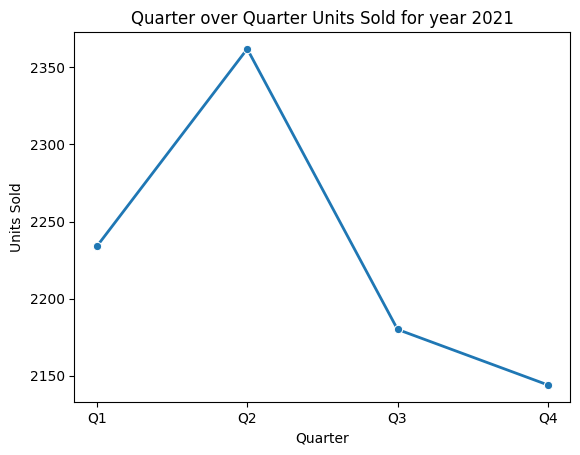

In [172]:
# Quarter over Quarter Analysis for 2021
line_plot("2021")

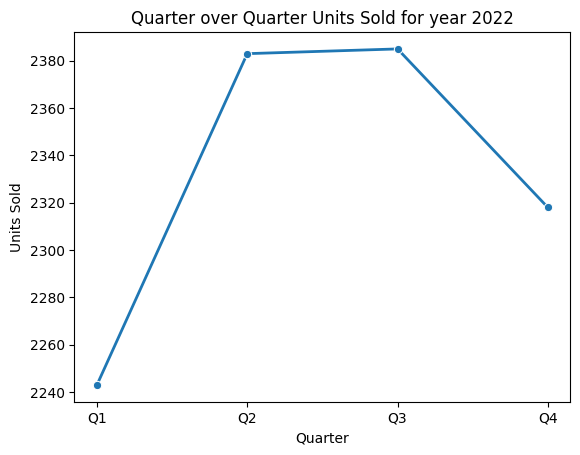

In [173]:
# Quarter over Quarter Analysis for 2022
line_plot("2022")

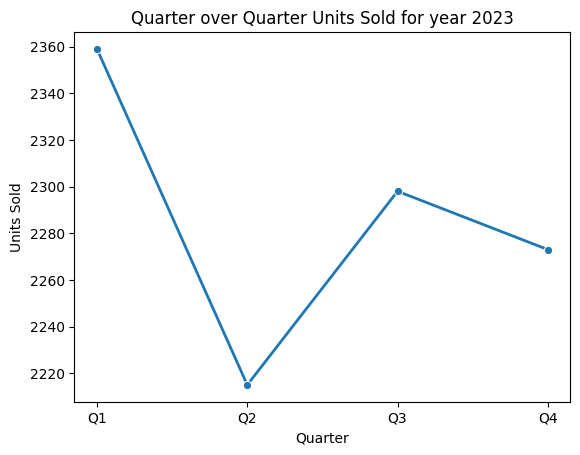

In [174]:
# Quarter over Quarter Analysis for 2022
line_plot("2023")

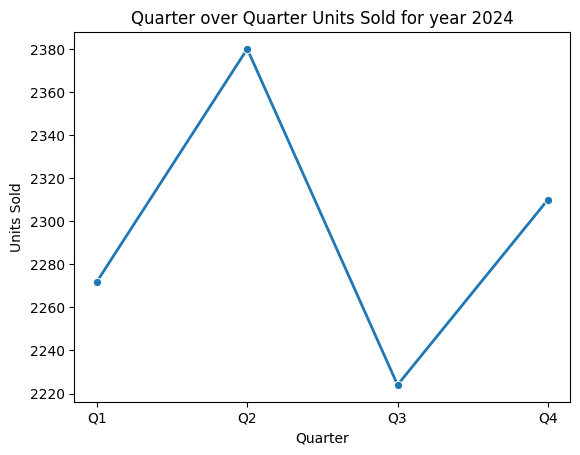

In [175]:
# Quarter over Quarter Analysis for 2022
line_plot("2024")

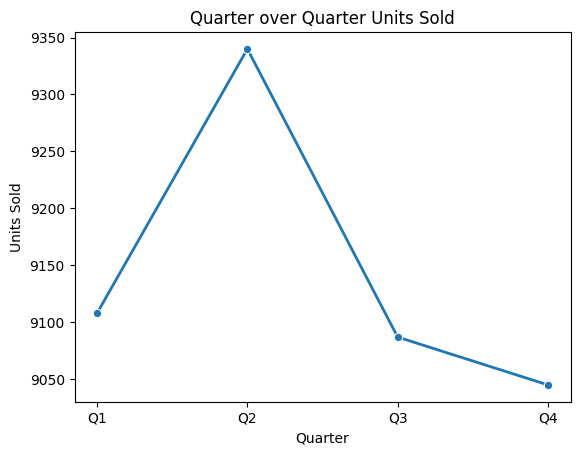

In [176]:
# Quarter Over Quarter Analysis
yearly = DF_Final.groupby("quarter")['units_sold'].sum().reset_index()

sns.lineplot(
    data=yearly,
    x='quarter',
    y='units_sold',
    marker='o',
    linewidth=2
)

plt.title('Quarter over Quarter Units Sold')
plt.xlabel('Quarter')
plt.ylabel('Units Sold')
plt.show()

# Observation
For three in four quarter and the in the overall consolidation the sales raises from Quarter 1 to Quarter 2 and drops after that seems to following a pattern.

In the months April, May, June the sales seems to be high.

# Revenue

<Axes: xlabel='revenue_usd', ylabel='Density'>

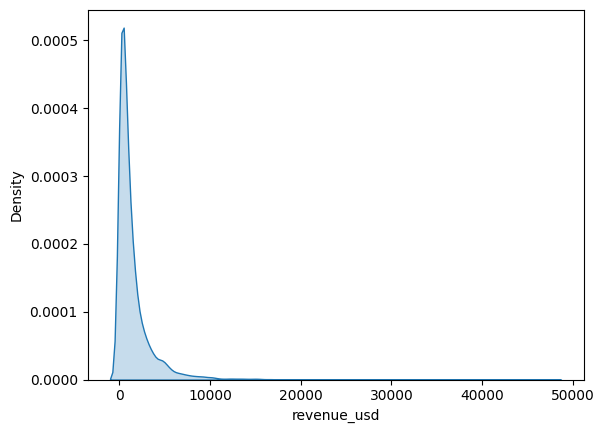

In [177]:
# Analysing the distribution of the revenue column
sns.kdeplot(data = DF_Final,x="revenue_usd",fill = True)

## Observation
The company generates revenue around 5000 USD all along the four years.

# Time Series Analysis for revenue

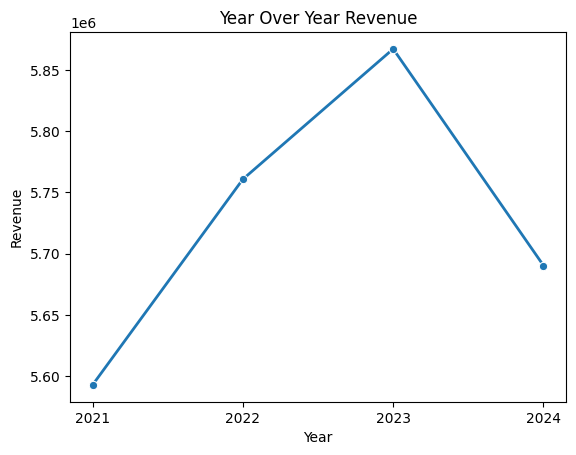

In [178]:
# Year Over Year Analysis
yearly = DF_Final.groupby("year")['revenue_usd'].sum().reset_index()

sns.lineplot(
    data=yearly,
    x='year',
    y='revenue_usd',
    marker='o',
    linewidth=2
)

plt.title('Year Over Year Revenue')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

# Observation
The revenue of the industry grows linearly from the 2021 to 2023 but after 2023 it faces sudden drop.

# Quarter Over Quarter Analysis

In [179]:
# Plotting the line plot for each year for different quarter
def final_plt(df,year):
    x = sns.lineplot(data = df, x = "quarter",y = "revenue_usd", marker = "o",linewidth = 2)
    x = plt.title('Quarter over Quarter of revenue for year '+ year)
    x = plt.xlabel('Quarter')
    x = plt.ylabel('Revenue')
    x = plt.show()
    return x

In [180]:
# Grouping the datset based on the quarter
def grouping_quarter(yearAfterFilter,year):
    DF_year = yearAfterFilter.groupby("quarter")["revenue_usd"].sum().reset_index()
    return final_plt(DF_year,year)


In [181]:
# Writing the Function for the Filtering
# Obseration on programming without passing the dataframe the dataframe can be used inside the function.
def line_plot_rev(year):
    DF_year = DF_Final[DF_Final["year"] == year].reset_index()
    DF_year = DF_year[["quarter","revenue_usd"]]
    return grouping_quarter(DF_year,year)


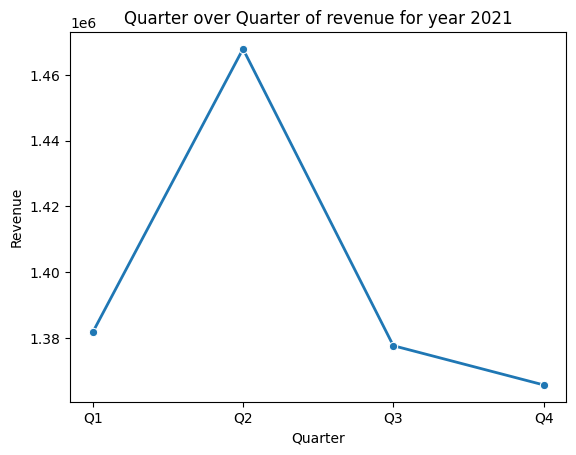

In [182]:
# Quarter over Quarter Analysis for 2021
line_plot_rev("2021")

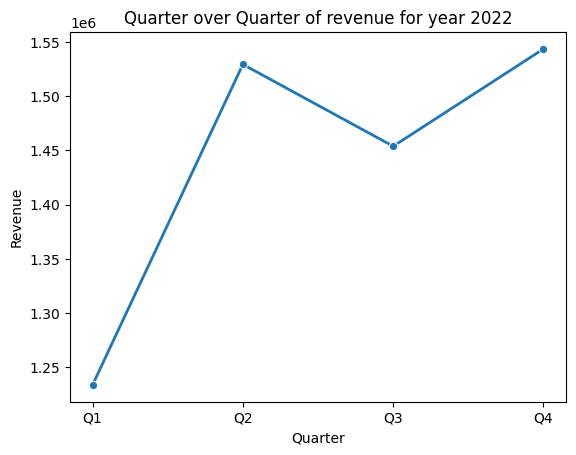

In [183]:
# Quarter over Quarter Analysis for 2021
line_plot_rev("2022")

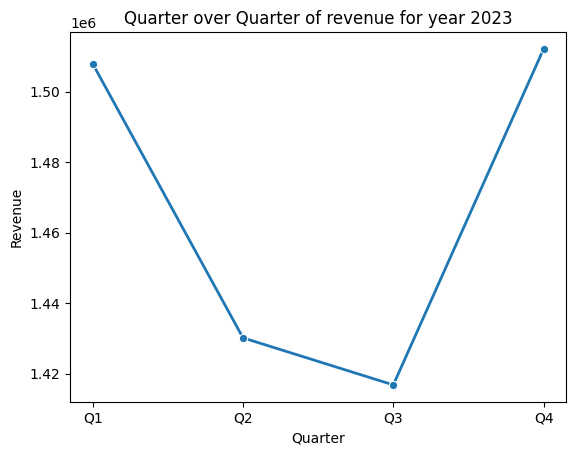

In [184]:
# Quarter over Quarter Analysis for 2021
line_plot_rev("2023")

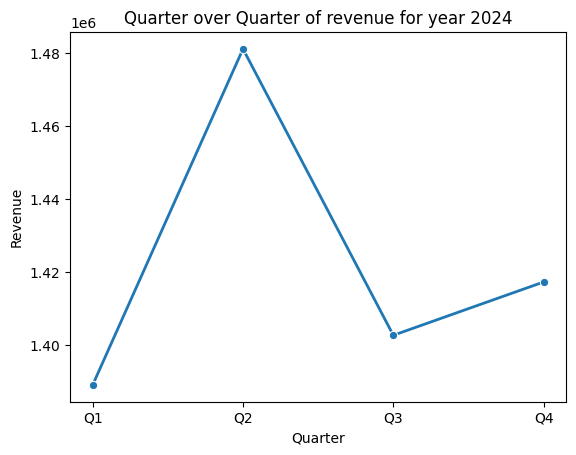

In [185]:
# Quarter over Quarter Analysis for 2021
line_plot_rev("2024")

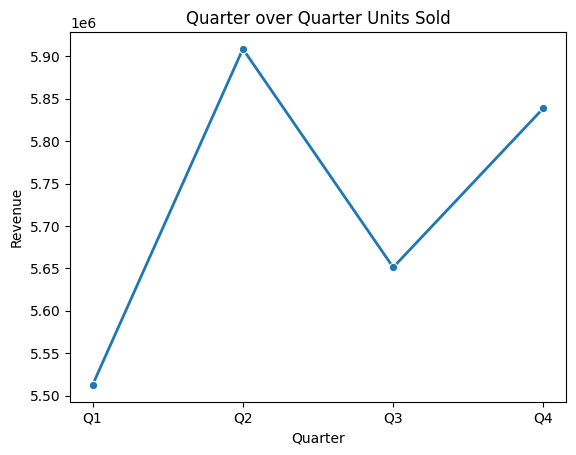

In [186]:
# Quarter over Quarter Analysis for revenue.
yearly = DF_Final.groupby("quarter")['revenue_usd'].sum().reset_index()

sns.lineplot(
    data=yearly,
    x='quarter',
    y='revenue_usd',
    marker='o',
    linewidth=2
)

plt.title('Quarter over Quarter Units Sold')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.show()

## Observation
 1.From the four year of the analysis the revenue seems to be reduced from the quarter 2 to the quater 3 then it raised again seems to be the month       July,August,September produces lowest revenue.
 
 2.The months April,May,June produces highest revenue.

 3.In the year of 2023 the revenue was very low from the rest of the year.

In [187]:
# Revenue with category 
Cat_wise_revenue = DF_Final.groupby('category')[["revenue_usd"]].sum()
Cat_wise_revenue

,revenue_usd
category,
Accessories,234760.98
Appliances,2253734.40
Galaxy A,1154772.22
Galaxy Buds,298759.24
Galaxy M,425853.53
Galaxy S,4728112.37
Galaxy Tab,2451712.69
Galaxy Watch,913148.29
Galaxy Z,2765867.41


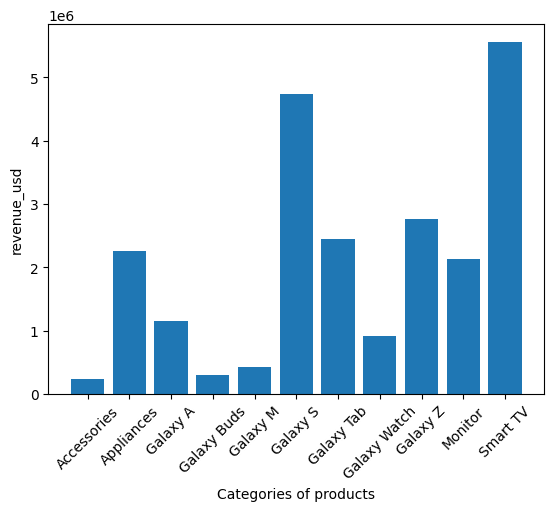

In [188]:
plt.bar(x=Cat_wise_revenue.index,height = Cat_wise_revenue["revenue_usd"])
plt.xticks(rotation = 45)
plt.xlabel("Categories of products")
plt.ylabel("revenue_usd")
plt.show()

## Observation
The categories Galaxy S and the Smart Tv generated highest revenues.

In [189]:
# Unit sold based on channel.
channel_wise_revenue = DF_Final.groupby(['sales_channel'])[["revenue_usd"]].sum()
channel_wise_revenue.sort_values("revenue_usd",inplace = True,ascending = False)
channel_wise_revenue

,revenue_usd
sales_channel,
Samsung Store,3432361.37
E-commerce Platform,3369992.99
Corporate / B2B,3346952.28
Third-Party Retailer,3285038.22
Carrier Store,3212142.04
Online (Samsung.com),3155638.03
Authorized Reseller,3109133.95


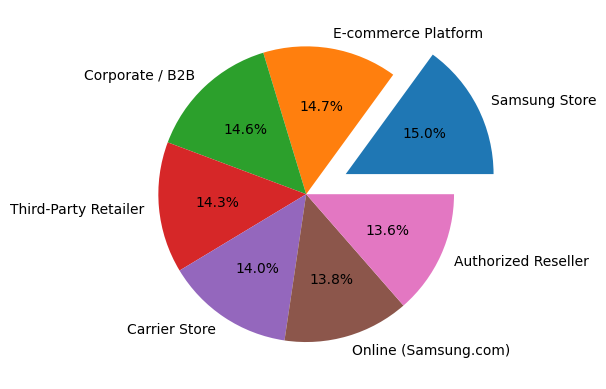

In [190]:
#Channel wise sales
plt.pie(x = channel_wise_revenue["revenue_usd"],labels = channel_wise_revenue.index,autopct = "%1.1f%%",explode = [0.3,0,0,0,0,0,0])
plt.show()

# Observation
The Sales channel Samsung Store generated highest rate of revenue among all other categories.

In [191]:
# Customer wise revenue generation
Cust_wise_revenue = DF_Final.groupby('customer_segment')[["revenue_usd"]].sum()
Cust_wise_revenue.sort_values("revenue_usd",inplace = True)
Cust_wise_revenue

,revenue_usd
customer_segment,
Education,4481623.94
Enterprise,4491693.89
Business,4545605.07
Individual,4643632.08
Government,4748703.90


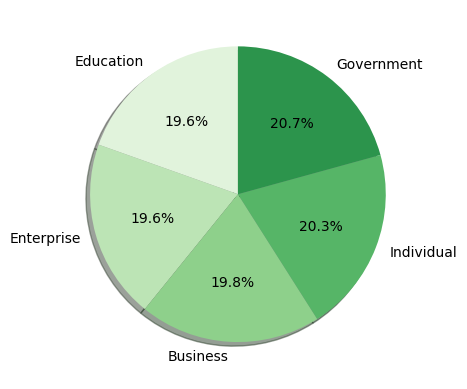

In [192]:
# Customer wise unit generation
color = sns.color_palette("Greens")
plt.pie(x = Cust_wise_revenue["revenue_usd"] ,labels = Cust_wise_revenue.index, colors = color,autopct = "%1.1f%%",shadow = True,startangle =90)
plt.show()

# Observation
1. Among all the customer segment the people from Government sector and the Individual sector were the sales was high.
2. People from all the sectors brought the company descent rate of revenue.

In [193]:
DF_Final

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,is_5g,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,sales_channel,payment_method,customer_segment,customer_age_group,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,1 TB,Graphite,No,1246.77,0,1,1246.77,1246.77,E-commerce Platform,Samsung Pay,Business,45–54,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,1 TB,Titanium Violet,Yes,809.84,10,2,728.86,1457.72,Authorized Reseller,Net Banking,Government,55+,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,128 GB,Awesome Black,Yes,410.19,12,6,360.97,2165.82,Corporate / B2B,Gift Card,Individual,25–34,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,NaN,Black,No,242.69,0,3,242.69,728.07,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,256 GB,Cream,Yes,1562.98,0,2,1562.98,3125.96,Authorized Reseller,Gift Card,Business,55+,3.0,Kept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15495,SAMS-00015496,2024-08-08,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Galaxy A54 5G,Galaxy A,64 GB,Awesome Violet,Yes,476.87,0,1,476.87,476.87,Samsung Store,BNPL (Buy Now Pay Later),Government,25–34,4.0,Kept
15496,SAMS-00015497,2024-08-10,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Neo QLED 8K QN900C,Smart TV,NaN,Black,No,4790.45,0,3,4790.45,14371.35,Carrier Store,EMI / Installment,Government,55+,NaN,Returned
15497,SAMS-00015498,2024-09-15,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung Galaxy Watch 6,Galaxy Watch,NaN,Cream,No,295.02,5,2,280.27,560.54,Online (Samsung.com),Credit Card,Enterprise,45–54,NaN,Kept
15498,SAMS-00015499,2024-09-16,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung 25L Microwave,Appliances,NaN,Silver,No,191.25,15,1,162.56,162.56,Third-Party Retailer,Debit Card,Business,18–24,3.3,Kept


In [194]:
# Category wise Null values 
DF_Final.groupby("category")["customer_rating"].apply(lambda x: x.isna().sum())

category
Accessories     597
Appliances      285
Galaxy A        504
Galaxy Buds     247
Galaxy M        225
Galaxy S        647
Galaxy Tab      431
Galaxy Watch    394
Galaxy Z        277
Monitor         295
Smart TV        349
Name: customer_rating, dtype: int64

In [195]:
# Ctaegory wise the values.
DF_Final.groupby("category")["customer_rating"].apply(lambda x: x.sum())

category
Accessories     5660.5
Appliances      2920.8
Galaxy A        5202.5
Galaxy Buds     2303.5
Galaxy M        2398.1
Galaxy S        6244.6
Galaxy Tab      4063.6
Galaxy Watch    4053.4
Galaxy Z        2892.7
Monitor         2818.3
Smart TV        3552.8
Name: customer_rating, dtype: float64

## Observation
 1.The customer_rating column have 50% of the null values in order to handle that I chosen to not handle or drop them since replacing them with the mean value gives us the biased observation,so replacing with median not going to create big impact since that will return the same value so not considering the null values will be best option to handle the null and finding the average customer rating for each category.

In [196]:
# Describing the customer rating for all the category.
DF_Describe = DF_Final.groupby("category")["customer_rating"].describe()
DF_Describe

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Accessories,1504.0,3.763630,0.701553,2.5,3.2,3.7,4.4,5.0
Appliances,767.0,3.808083,0.740836,2.5,3.2,3.9,4.5,5.0
Galaxy A,1388.0,3.748199,0.729928,2.5,3.1,3.7,4.4,5.0
Galaxy Buds,622.0,3.703376,0.721337,2.5,3.1,3.7,4.3,5.0
Galaxy M,636.0,3.770597,0.711879,2.5,3.2,3.8,4.4,5.0
Galaxy S,1669.0,3.741522,0.719967,2.5,3.1,3.7,4.3,5.0
Galaxy Tab,1093.0,3.717841,0.735259,2.5,3.0,3.7,4.4,5.0
Galaxy Watch,1092.0,3.711905,0.720096,2.5,3.1,3.7,4.3,5.0
Galaxy Z,781.0,3.703841,0.712695,2.5,3.1,3.7,4.3,5.0


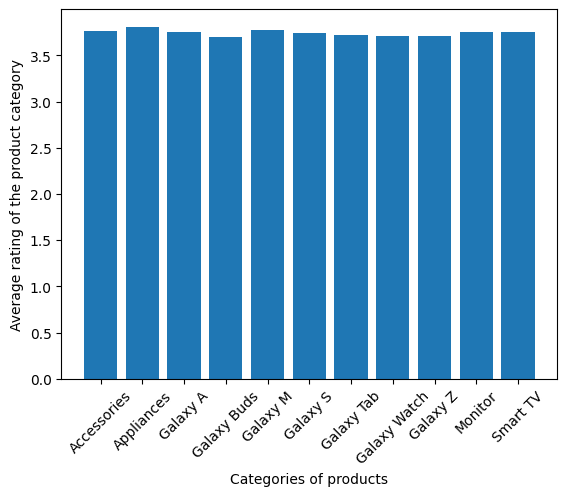

In [197]:
plt.bar(x=DF_Describe.index,height = DF_Describe["mean"] )
plt.xticks(rotation = 45)
plt.xlabel("Categories of products")
plt.ylabel("Average rating of the product category")
plt.show()

# Observation 
The average rating of the product is around and above 3.7.

# Return Statement 

In [198]:
DF_Final["return_status"].value_counts()

return_status
Kept         13315
Returned      1427
Exchanged      758
Name: count, dtype: int64

In [199]:
DF_Final

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,is_5g,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,sales_channel,payment_method,customer_segment,customer_age_group,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,1 TB,Graphite,No,1246.77,0,1,1246.77,1246.77,E-commerce Platform,Samsung Pay,Business,45–54,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,1 TB,Titanium Violet,Yes,809.84,10,2,728.86,1457.72,Authorized Reseller,Net Banking,Government,55+,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,128 GB,Awesome Black,Yes,410.19,12,6,360.97,2165.82,Corporate / B2B,Gift Card,Individual,25–34,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,NaN,Black,No,242.69,0,3,242.69,728.07,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,256 GB,Cream,Yes,1562.98,0,2,1562.98,3125.96,Authorized Reseller,Gift Card,Business,55+,3.0,Kept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15495,SAMS-00015496,2024-08-08,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Galaxy A54 5G,Galaxy A,64 GB,Awesome Violet,Yes,476.87,0,1,476.87,476.87,Samsung Store,BNPL (Buy Now Pay Later),Government,25–34,4.0,Kept
15496,SAMS-00015497,2024-08-10,2024,Q3,August,Vietnam,Asia,Nha Trang,Samsung Neo QLED 8K QN900C,Smart TV,NaN,Black,No,4790.45,0,3,4790.45,14371.35,Carrier Store,EMI / Installment,Government,55+,NaN,Returned
15497,SAMS-00015498,2024-09-15,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung Galaxy Watch 6,Galaxy Watch,NaN,Cream,No,295.02,5,2,280.27,560.54,Online (Samsung.com),Credit Card,Enterprise,45–54,NaN,Kept
15498,SAMS-00015499,2024-09-16,2024,Q3,September,Vietnam,Asia,Nha Trang,Samsung 25L Microwave,Appliances,NaN,Silver,No,191.25,15,1,162.56,162.56,Third-Party Retailer,Debit Card,Business,18–24,3.3,Kept


In [200]:
DF_Category = pd.DataFrame(DF_Final.groupby("category")["return_status"].value_counts())
DF_Category.reset_index(inplace = True)

In [201]:
# Foming the pivot table for category and the return status.
Return_status = DF_Category.pivot(index = "category", columns="return_status", values="count")
Return_status.reset_index(inplace = True)
Return_status

return_status,category,Exchanged,Kept,Returned
0,Accessories,127,1776,198
1,Appliances,49,908,95
2,Galaxy A,87,1634,171
3,Galaxy Buds,40,749,80
4,Galaxy M,47,735,79
5,Galaxy S,119,1987,210
6,Galaxy Tab,72,1295,157
7,Galaxy Watch,73,1289,124
8,Galaxy Z,47,896,115
9,Monitor,45,915,86


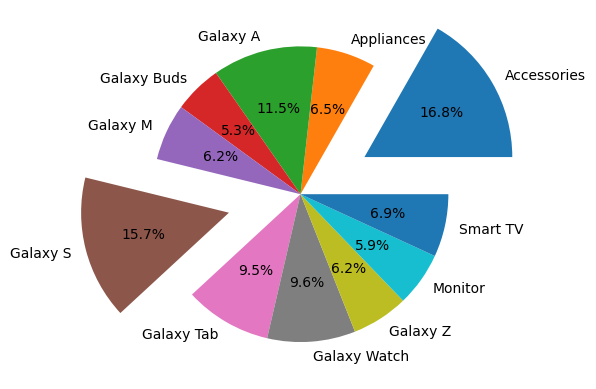

In [202]:
# Visualizing using the pie chart 
plt.pie(data = Return_status,x="Exchanged",labels = "category",autopct = "%1.1f%%",explode = [0.5,0,0,0,0,0.5,0,0,0,0,0])
plt.show()

# Observation 
The Category Accessories and the Galaxy S seems to have high exchange rate.

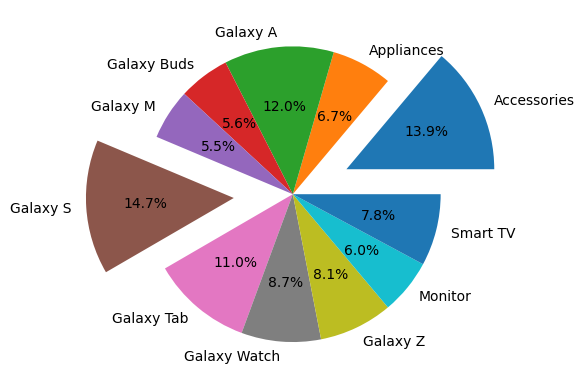

In [203]:
# Visualizing using the pie chart 
plt.pie(data = Return_status,x="Returned",labels = "category",autopct = "%1.1f%%",explode = [0.4,0,0,0,0,0.4,0,0,0,0,0])
plt.show()

# OBSERVATION
The product the Galaxy S and the Accessories have high return status.

## Project Summary

This project is about analyzing Samsung's global product sales data to find useful patterns and insights that can help in business decisions. I picked this dataset from Kaggle since it had a good mix of sales, product, and customer related columns to work with.
Dataset: Samsung Global Product Sales Dataset from Kaggle, having 15,500 rows and 28 columns. It covers sales from 2021 to 2024 across different countries, regions, product categories and customer types.
    
## What I did:

First I did a data quality check where I found the shape of the data, checked the datatypes, found null values in storage, previous_device_os and customer_rating columns, checked for duplicates (didn't find any) and also checked outliers using boxplot.
After that I created a new dataframe with only the columns needed for analysis and removed the currency related columns since I was already working with the USD columns.
Then I started the actual analysis. First I checked how unit price is distributed and tried to see if it has any relation with customer age group, storage type and discount over different quarters.
Next I checked units sold and revenue with respect to category, region, sales channel and customer segment to understand which of these are performing well and which are not.
I also did time series analysis to see how units sold and revenue changed year over year and quarter over quarter, to check for any seasonal pattern.
Lastly I checked customer rating for each category and also analyzed the return and exchange status to see which products have more return/exchange issues.

## Insights I found:

Most of the customers are buying products around $200 price range and there is no big difference in price preference between different age groups. Discount percentage is also more or less same across all quarters so discount doesn't seem to depend on time.
Galaxy S and Accessories are the categories which sold the most, while Galaxy Buds is the lowest performing category and might need some improvement in marketing. Europe and Asia are the regions where most of the units were sold, around 12,500 and 10,700 units, which is way more than other regions. All sales channels have almost similar performance with Corporate/B2B slightly ahead. Among customer segments, Individual customers bought the most units followed by Government and Business.

Talking about the trend, units sold increased from 2021 to 2022 but started dropping after that. Unit price also went up from 2021 to 2023 and then dropped. If we look at quarters, sales are usually high in Q2 (April-June) and low in Q3 (July-September), so there seems to be a seasonal pattern here.

For revenue, it kept growing from 2021 to 2023 but then dropped suddenly. Galaxy S and Smart TV are the categories generating the highest revenue. Samsung Store is the channel which generates the most revenue and Government + Individual segments contribute the most to revenue.
Customer rating is good overall, mostly above 3.7 out of 5 for all categories. But Galaxy S and Accessories have higher exchange and return rates compared to other categories, which is a little concerning since these are also the top selling products, so there might be some quality issue or the product is not matching customer expectations.

## What can be done based on this:

1. Need to find out why revenue and units sold dropped after 2023, whether it's because of price increase, region issue or category issue.
2. Galaxy Buds needs better marketing or promotion since its sales are low compared to others.
3. Should check why Galaxy S and Accessories have more returns/exchanges even though they sell the most, maybe a quality check is needed.
4. Since Q2 has high sales, planning stock and offers around that time could help, and also find ways to boost Q3 sales.

## Tools used: Python, Pandas, NumPy, Matplotlib, Seaborn and Statsmodels for mosaic plot.

## About the null values: 
I didn't remove the null values from storage and customer_rating columns directly from the whole dataset because that would also remove other useful data present in those rows. Also while finding average rating using describe() and mean(), pandas automatically skips the null values, so the average is correct without doing anything extra.
